In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("email_spam_detection.csv")
df

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


In [4]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0


In [5]:
df.tail

<bound method NDFrame.tail of       Email_ID          Sender_Email               Subject  Email_Length  \
0            1                                     Meeting           NaN   
1            2     user1@outlook.com        Security Alert          87.0   
2            3       user2@yahoo.com             Win Prize          69.0   
3            4       user3@gmail.com               Invoice          61.0   
4            5     user4@company.com               Meeting          99.0   
...        ...                   ...                   ...           ...   
6995      6996    user6995@gmail.com             Greetings          93.0   
6996      6997    user6996@yahoo.com                 Offer         107.0   
6997      6998    user6997@gmail.com  Account Verification         222.0   
6998      6999  user6998@outlook.com             Win Prize         164.0   
6999      7000  user6999@company.com             Greetings         168.0   

      Num_Links  Num_Special_Chars  Capital_Words  Has_At

In [6]:
df.shape

(7000, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


In [8]:
df.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000
max,7000.000000,265.000000,99.000000,28.000000,59.000000,1.000000,1.000000


In [9]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [10]:
df["Sender_Email"]=df["Sender_Email"].replace("",np.nan)

In [11]:
df["Sender_Email"].fillna("unknown@example.com",inplace=True)


0                           
1          user1@outlook.com
2            user2@yahoo.com
3            user3@gmail.com
4          user4@company.com
                ...         
6995      user6995@gmail.com
6996      user6996@yahoo.com
6997      user6997@gmail.com
6998    user6998@outlook.com
6999    user6999@company.com
Name: Sender_Email, Length: 7000, dtype: str

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.dtypes

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [35]:
(df["Num_Special_Chars"]==-1).sum()

np.int64(23)

In [36]:
(df["Num_Links"]==99).sum()

np.int64(17)

In [37]:
df.loc[df["Num_Special_Chars"]==-1,"Num_Special_Chars"]=np.nan
df.loc[df["Num_Links"]==99,"Num_Links"]=np.nan

In [38]:
df["Email_Length"].fillna(df["Email_Length"].median(),inplace=True)
df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median(),inplace=True)
df["Num_Links"].fillna(df["Num_Links"].median(),inplace=True)

0       1.0
1       2.0
2       0.0
3       0.0
4       2.0
       ... 
6995    1.0
6996    0.0
6997    7.0
6998    6.0
6999    1.0
Name: Num_Links, Length: 7000, dtype: float64

In [39]:
for col in ["Email_Length","Num_Links","Num_Special_Chars"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    outliers = df[(df[col]<lower) | (df[col]>upper)]
    print(f"{col} Outliers:",len(outliers))

Email_Length Outliers: 0
Num_Links Outliers: 283
Num_Special_Chars Outliers: 26


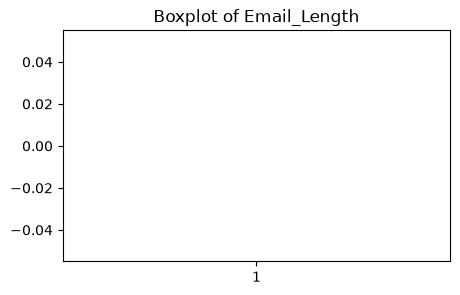

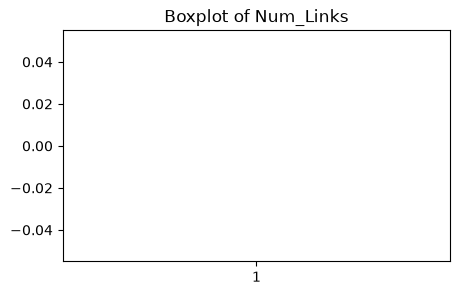

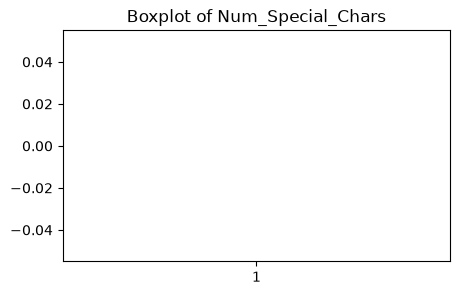

In [41]:
for col in ["Email_Length","Num_Links","Num_Special_Chars"]:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
df["Spam"].value_counts()

Spam
0    4864
1    2136
Name: count, dtype: int64

In [15]:
df.to_csv("email_spam_detection_cleaned.csv",index=False)

In [16]:
print("Cleaned file saved as:email_spam_detection_cleaned.csv")

Cleaned file saved as:email_spam_detection_cleaned.csv


In [17]:
print("File saved successfully")

File saved successfully
